# 11_数据预处理方法-类别编码

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 相关性图只选择编码后的数值列，避免把原始字符串列混入；更新稀疏独热编码参数。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天咱们来聊聊数据预处理中的类别编码\~

首先，为什么需要类别编码？

- **计算机理解数字**：大部分机器学习算法只能处理数字，如果直接输入文字数据，算法无法识别里面的信息。
- **比较和计算**：数字比起文字来说，便于比较、计算和进行数学运算，机器处理起来更快。

#### 类别编码是怎么做的？

最最常见的方法：

1. **标签编码**

   - **原理**：把每个不同的文字类别分配一个独特的数字。比如，“红色”可能被编码成0，“蓝色”编码成1，“绿色”编码成2。
   - **优点**：简单直接，编码后的数据占用空间小。
   - **缺点**：有可能让模型误以为这些数字之间有大小顺序（比如2大于1），而实际上它们只代表不同的类别，不存在大小关系。
2. **独热编码（One-Hot Encoding）**

   - **原理**：对于每个类别，创建一个二元变量（0或1）。例如，如果类别有“红色”、“蓝色”、“绿色”，则会生成3列数据：当“红色”出现时，对应列填1，其余列填0。
   - **优点**：不会让模型产生错误的大小比较，因为每个类别都是独立的。
   - **缺点**：当类别非常多时，会产生大量的二元变量，数据维度会急剧增加，这可能导致模型计算量增大。

## 原理详解

类别编码主要包括**标签编码**和**独热编码**两种方法。

虽然这两种方法看似简单，但其背后的数学描述能帮助我们更好地理解数据预处理的本质，对于后续的模型构建也具有一定的指导意义。

### 1. 标签编码（Label Encoding）

假设有一个类别特征 $X$其取值集合为：


$$
C = \{ c_1, c_2, \dots, c_k \}
$$


其中 $k$表示该特征的类别总数。标签编码的目标是构造一个映射函数


$$
f: C \to \{0, 1, 2, \dots, k-1\}
$$


使得对每个样本的类别值 $x_i \in C$，其对应的数值形式为


$$
y_i = f(x_i)
$$


这种映射把每个类别用一个整数表示，实际上是一种离散标识。

例如，对于类别集合


$$
C = \{\text{红色}, \text{蓝色}, \text{绿色}\}
$$


可以构造一个简单映射


$$
f(\text{红色}) = 0, \quad f(\text{蓝色}) = 1, \quad f(\text{绿色}) = 2.
$$


**优点：**

- 数学上映射函数 $f$是一一对应关系（若类别没有内在的序关系），并且该方法极其简单。
- 计算和存储上，直接将类标签转为整数时资源占用较低。

**局限性：**

- 数值编码隐含了“顺序”和“大小”信息，比如2被认为比1“更大”，这在无序类别中是没有实际意义的。在某些模型（例如线性模型）中，可能会因为数值上的大小关系而产生误解。

#### 算法流程

1. **确定类别集合：**扫描整个数据集，确定特定特征的所有唯一类别，记为集合 $C$。
2. **建立映射函数：**根据 $C$中类别的排序（可以是按字典序、出现频次等）建立一个映射 $f: C \to \{0, 1, \dots, k-1\}$。
3. **转换数据：**对数据集中的每个样本 $x_i$使用映射函数 $f$得到数字 $y_i = f(x_i)$。
4. **输出转换结果：**形成新的数字型特征向量，供后续模型学习使用。

### 2. 独热编码（One-Hot Encoding）

对于同样的类别集合  
$C = \{ c_1, c_2, \dots, c_k \},$  
独热编码的基本思想是将每个类别映射为一个 $k$维的二进制向量，这个向量中仅有一个位置为1，其余均为0。

形式上，对于任意一个类别值 $x \in C$，其独热编码向量表示为  
$\mathbf{v}(x) = \left[ I(x = c_1), I(x = c_2), \dots, I(x = c_k) \right]$  
其中，指示函数 $I(\cdot)$定义为  
$I(x = c_j)=\begin{cases}1, & \text{若 } x = c_j, \\0, & \text{否则.}\end{cases}$

例如，对于  
$C = \{\text{红色}, \text{蓝色}, \text{绿色}\},$  
如果 $x = \text{蓝色}$，则  
$\mathbf{v}(x) = [0, 1, 0].$

这种表示方式在数学上保证了每个类别被表示在一个独立的维度上，任何两个不同类别对应的向量之间都是正交的（内积为零），这有助于消除类别间隐含的大小关系问题。

#### 数学推导

考虑任一输入样本 $x$和类别集合 $C$。

- 对于 $j \in \{1, \dots, k\}$，定义：  
$v_j(x) = I(x = c_j)$
- 则整个样本 $x$的独热编码向量为：  
$\mathbf{v}(x) = \left( v_1(x), v_2(x), \dots, v_k(x) \right)^{\mathrm{T}}.$

这种编码方法具有以下数学性质：

- 单位长度的稀疏向量：向量中仅有一个元素为1，其余均为0，因此向量的 $L_1$范数等于1。
- 正交性：设 $\mathbf{v}(c_i)$和 $\mathbf{v}(c_j)$为两个不同类别 $c_i$和 $c_j$的独热编码，则：  
$\mathbf{v}(c_i)^\mathrm{T} \mathbf{v}(c_j) = 0 \quad \text{（当 } i\neq j\text{时）.}$
- 欧几里得距离：对于任何两个不同类别 $c_i$与 $c_j$，他们的欧几里得距离 $d$满足：  
$d\left( \mathbf{v}(c_i), \mathbf{v}(c_j) \right) = \sqrt{2},$  
表明各个类别之间在向量空间里彼此等距。

#### 算法流程

独热编码的算法流程如下：

1. 确定类别集合：遍历数据集中的某个特征，抽取所有唯一的类别构成集合 $C = \{ c_1, c_2, \dots, c_k \}$。
2. 定义向量空间：为每一个类别确定一个 $k$维向量空间，其中每个类别对应一个唯一的维度。
3. 生成编码向量：对于每个样本 $x_i$，构造一个向量 $\mathbf{v}(x_i)$：

   - 对 $j = 1$到 $k$，计算 $v_j(x_i)=I(x_i = c_j)$。
   - 形成 $\mathbf{v}(x_i) = [v_1(x_i), v_2(x_i), \dots, v_k(x_i)]^\mathrm{T}$。
4. 转换整个数据集：将所有样本的原始类别数据 $X = \{ x_1, x_2, \dots, x_n \}$通过上述方法转换为矩阵形式：  
$\mathbf{V} =\begin{pmatrix}\mathbf{v}(x_1)^\mathrm{T} \\\mathbf{v}(x_2)^\mathrm{T} \\\vdots \\\mathbf{v}(x_n)^\mathrm{T}\end{pmatrix}_{n \times k}$  
其中 $n$为样本总数。
5. 后续处理：得到的矩阵 $\mathbf{V}$可以作为输入传入后续的机器学习算法中。

### 进一步对比

- **标签编码 vs. 独热编码：**

  - 标签编码用的是一个映射 $f$将类别映射到整数集合，映射简单，但可能会引入顺序信息；
  - 独热编码则完全避免了数值大小的隐含关系，每个类别在向量空间中完全独立，更适用于无序类别特征。但代价是可能会引入高维度的数据表示，特别当类别数量 $k$很大时，会导致“维度灾难”。
- 数学上处理离散变量：无论是标签编码还是独热编码，本质上都是将离散的符号数据映射到实数域上的一个子集，从而使得在数学上可以进行进一步的计算（如内积、距离测量、线性组合等）。
- **延伸：对于具有内在顺序或者等级关系的类别（例如“低、中、高”），可以采用有序编码**，这种方法实际上利用了类别之间的顺序信息，即  
$c_1 < c_2 < \dots < c_k$  
数值赋值时可以按顺序赋予类似整数 $0, 1, \dots, k-1$，同时在模型中保留顺序信息。但是这种方式在无序类别上就不适合。

## 完整案例

下面给出一个详细的实际案例，演示如何在数据预处理阶段对类别数据进行编码\~

初始数据集样本：
     Color    Brand  ProductType  Price  Sales
0  Yellow  Brand_B     Clothing  53.26     32
1  Purple  Brand_D         Food  37.49     24
2   Green  Brand_D    Furniture  59.24     30
3  Purple  Brand_A    Furniture  48.15     16
4  Purple  Brand_B  Electronics  44.77     21
Label Encoding mapping for Color: {'Blue': np.int64(0), 'Green': np.int64(1), 'Purple': np.int64(2), 'Red': np.int64(3), 'Yellow': np.int64(4)}
Label Encoding mapping for Brand: {'Brand_A': np.int64(0), 'Brand_B': np.int64(1), 'Brand_C': np.int64(2), 'Brand_D': np.int64(3)}
Label Encoding mapping for ProductType: {'Clothing': np.int64(0), 'Electronics': np.int64(1), 'Food': np.int64(2), 'Furniture': np.int64(3)}

独热编码后数据集样本（部分列展示）：
     Color    Brand  ProductType  Price  Sales  Color_Blue  Color_Green  \
0  Yellow  Brand_B     Clothing  53.26     32       False        False   
1  Purple  Brand_D         Food  37.49     24       False        False   
2   Green  Brand_D    Furniture  59.24     30       Fal

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11565/2397468687.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='Set1')
/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11565/2397468687.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='Set1')
/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11565/2397468687.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='Set1')


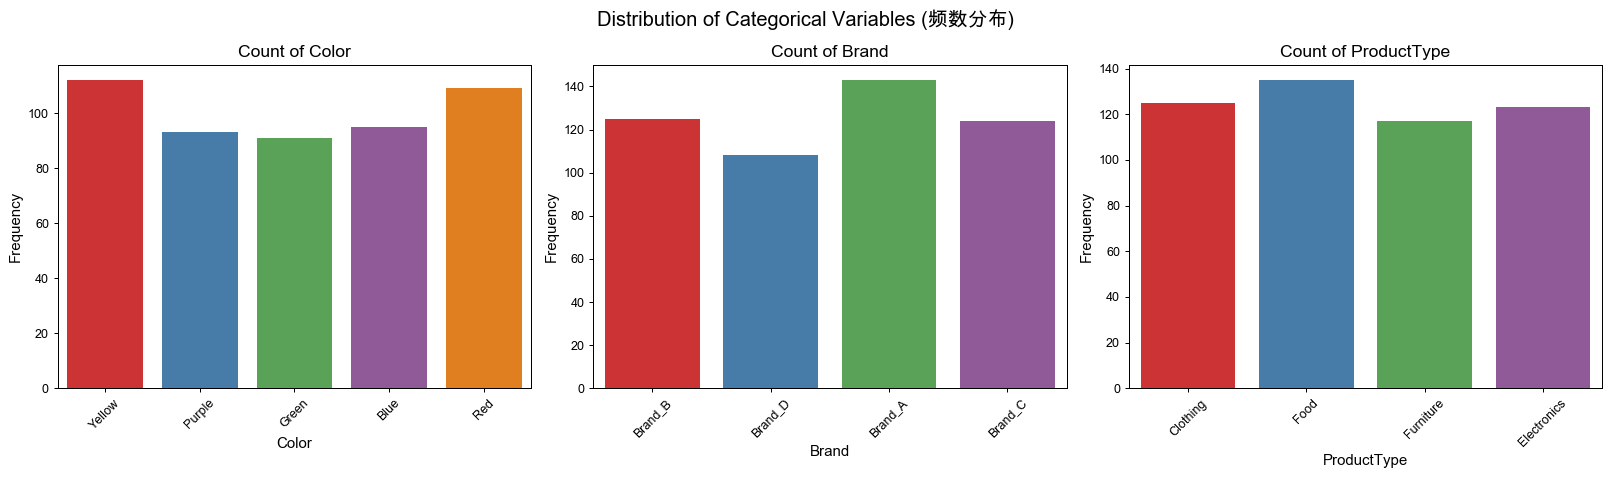

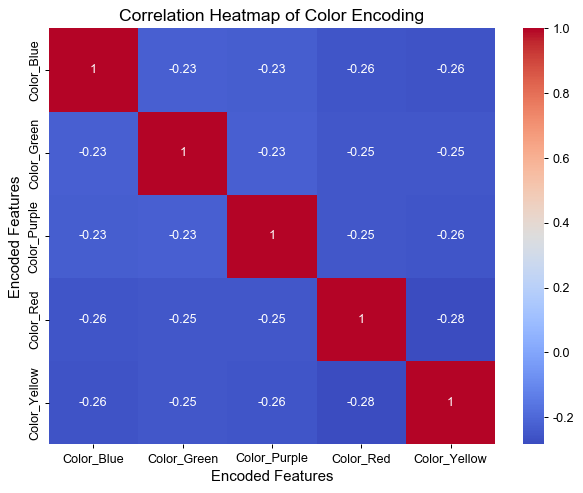

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11565/2397468687.py:170: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=categorical_feature, y=numeric_feature, data=df, palette='Paired')


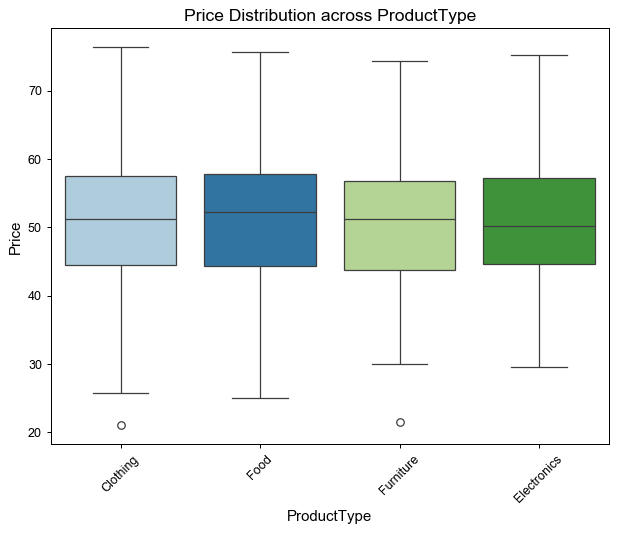


Processed data type (sparse matrix expected): <class 'numpy.ndarray'>
Processed data shape: (500, 15)
Label Encoding mapping for Color: {'Blue': np.int64(0), 'Green': np.int64(1), 'Purple': np.int64(2), 'Red': np.int64(3), 'Yellow': np.int64(4)}
Label Encoding mapping for Brand: {'Brand_A': np.int64(0), 'Brand_B': np.int64(1), 'Brand_C': np.int64(2), 'Brand_D': np.int64(3)}
Label Encoding mapping for ProductType: {'Clothing': np.int64(0), 'Electronics': np.int64(1), 'Food': np.int64(2), 'Furniture': np.int64(3)}


/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11565/2397468687.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='Set1')
/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11565/2397468687.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='Set1')
/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11565/2397468687.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='Set1')


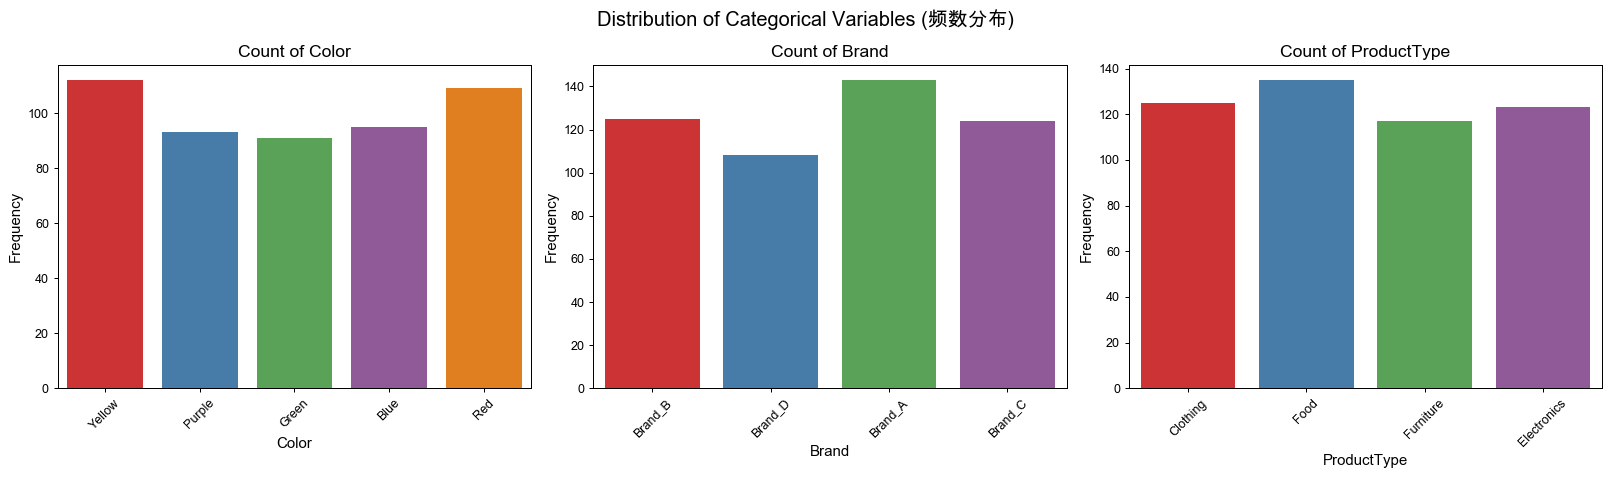

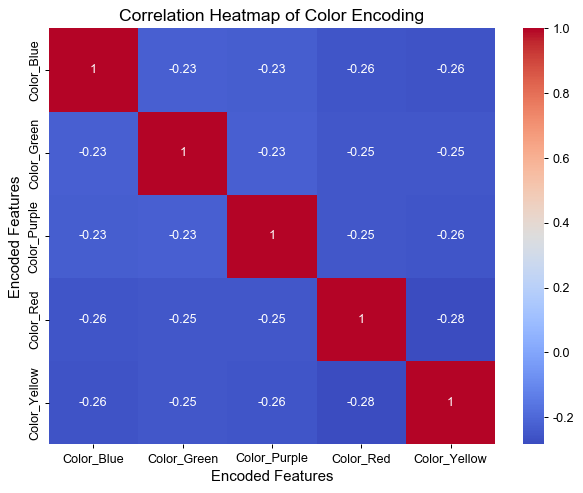

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11565/2397468687.py:170: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=categorical_feature, y=numeric_feature, data=df, palette='Paired')


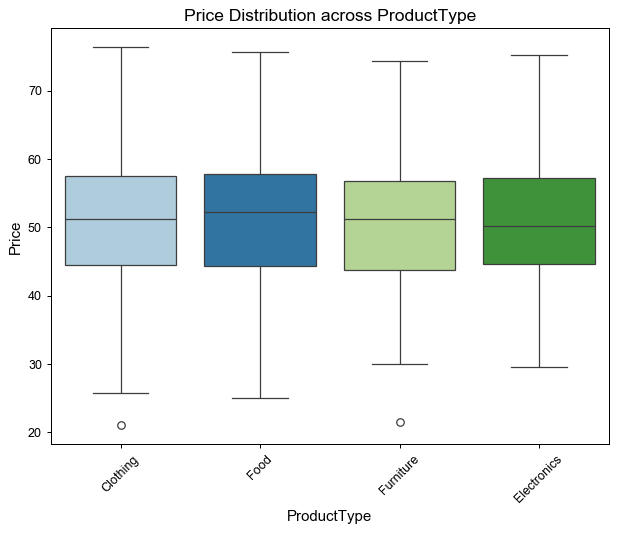

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from scipy import sparse


# 1. 数据生成与数据描述
def create_dataset(num_samples=500, random_state=42):

    np.random.seed(random_state)
    
    # 定义类别特征取值
    colors = ['Red', 'Blue', 'Green', 'Yellow', 'Purple']
    brands = ['Brand_A', 'Brand_B', 'Brand_C', 'Brand_D']
    product_types = ['Electronics', 'Clothing', 'Food', 'Furniture']
    
    # 随机生成类别数据
    color_data = np.random.choice(colors, size=num_samples)
    brand_data = np.random.choice(brands, size=num_samples)
    product_type_data = np.random.choice(product_types, size=num_samples)
    
    # 随机生成数值特征, 比如价格、销量
    price_data = np.random.normal(loc=50, scale=10, size=num_samples)  # 均值50，标准差10
    # 销量数据与产品种类、品牌或颜色可能存在隐含关系，这里为了简单模拟，随机生成
    sales_data = np.random.poisson(lam=20, size=num_samples)
    
    # 创建DataFrame
    df = pd.DataFrame({
        'Color': color_data,
        'Brand': brand_data,
        'ProductType': product_type_data,
        'Price': np.round(price_data, 2),
        'Sales': sales_data
    })
    return df

# 生成数据集
df = create_dataset(num_samples=500)
print("初始数据集样本：\n", df.head())

# 2. 类别编码
# 标签编码（Label Encoding）
def apply_label_encoding(df, categorical_features):
    """
    对指定类别变量进行标签编码，将文本转换为整数编码。
    参数:
        df: 原始数据的DataFrame
        categorical_features: 需要编码的类别变量列表
    返回:
        df_le: 标签编码后数据集副本
        mapping_dict: 存储每个特征的编码映射关系
    """
    df_le = df.copy()
    mapping_dict = {}
    for feature in categorical_features:
        le = LabelEncoder()
        df_le[feature + '_LE'] = le.fit_transform(df_le[feature])
        mapping_dict[feature] = dict(zip(le.classes_, le.transform(le.classes_)))
        # 输出每个类别变量的编码映射关系
        print(f"Label Encoding mapping for {feature}: {mapping_dict[feature]}")
    return df_le, mapping_dict

categorical_features = ['Color', 'Brand', 'ProductType']
df_le, mapping_dict = apply_label_encoding(df, categorical_features)

# 独热编码（One-Hot Encoding）
def apply_onehot_encoding(df, categorical_features):
    """
    对指定类别变量进行独热编码，转换为二进制向量。
    参数:
        df: 原始数据的DataFrame
        categorical_features: 需要编码的类别变量列表
    返回:
        df_ohe: 独热编码后数据集副本
    """
    df_ohe = df.copy()
    # 使用pd.get_dummies()方法进行独热编码，便于观察结果
    for feature in categorical_features:
        dummies = pd.get_dummies(df_ohe[feature], prefix=feature)
        df_ohe = pd.concat([df_ohe, dummies], axis=1)
        # 可选择删除原有的类别变量，避免重复信息：df_ohe.drop([feature], axis=1, inplace=True)
    return df_ohe

df_ohe = apply_onehot_encoding(df, categorical_features)
print("\n独热编码后数据集样本（部分列展示）：\n", df_ohe.head())

# 稀疏矩阵优化：若类别个数众多，独热编码后的数据矩阵中大多数值为0，此时可以采用scipy.sparse对象进行存储优化
def apply_sparse_onehot_encoding(df, categorical_features):
    """
    对指定类别变量进行独热编码，并将结果转换为稀疏矩阵，优化高维数据存储。
    参数:
        df: 原始数据的DataFrame
        categorical_features: 需要编码的类别变量列表
    返回:
        sparse_matrix: 拼接后的稀疏矩阵格式数据
        feature_names: 每列对应的特征名称
    """
    # 针对多个特征逐个处理
    sparse_matrices = []
    feature_names = []
    
    for feature in categorical_features:
        dummies = pd.get_dummies(df[feature], prefix=feature, sparse=True)
        sparse_matrices.append(dummies.sparse.to_coo())
        feature_names.extend(dummies.columns.tolist())
    
    # 使用scipy.sparse.hstack拼接所有稀疏矩阵
    combined_sparse = sparse.hstack(sparse_matrices)
    return combined_sparse, feature_names

sparse_matrix, sparse_feature_names = apply_sparse_onehot_encoding(df, categorical_features)
print("\nSparse matrix shape (One-Hot Encoding):", sparse_matrix.shape)
print("Feature names:", sparse_feature_names)

# 3. 数据可视化与分析
# 本部分通过可视化手段，展示类别变量的分布、编码后变量之间的相关性以及数值变量与类别的关系。

def visualize_categorical_distribution(df, categorical_features):
    """
    绘制每个类别变量的频数分布柱状图。
    参数:
        df: 数据集DataFrame
        categorical_features: 类别变量列表
    """
    plt.figure(figsize=(18, 5))
    for i, feature in enumerate(categorical_features, 1):
        plt.subplot(1, len(categorical_features), i)
        sns.countplot(x=feature, data=df, palette='Set1')
        plt.title(f'Count of {feature}', fontsize=14)
        plt.xlabel(feature, fontsize=12)     
        plt.ylabel('Frequency', fontsize=12) 
        plt.xticks(rotation=45)
        plt.tight_layout()
    plt.suptitle("Distribution of Categorical Variables (频数分布)", fontsize=16, y=1.05)
    plt.show()
    
visualize_categorical_distribution(df, categorical_features)

def visualize_encoded_heatmap(df_ohe, original_feature='Color'):
    """
    绘制由独热编码生成的特征之间的相关性热力图，用于分析不同类别变量之间的共现关系。
    参数:
        df_ohe: 包含独热编码特征的DataFrame
        original_feature: 指定查看哪个类别变量的独热编码结果
    """
    # 筛选指定feature的独热编码列
    encoded_columns = [col for col in df_ohe.columns if col.startswith(original_feature + "_")]
    corr_matrix = df_ohe[encoded_columns].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', cbar=True)
    plt.title(f'Correlation Heatmap of {original_feature} Encoding', fontsize=14)
    plt.xlabel('Encoded Features', fontsize=12)
    plt.ylabel('Encoded Features', fontsize=12)
    plt.show()
    
visualize_encoded_heatmap(df_ohe, original_feature='Color')

def visualize_numeric_distribution(df, categorical_feature, numeric_feature):
    """
    绘制箱线图，展示不同类别下数值变量的分布情况。
    参数:
        df: 数据集DataFrame
        categorical_feature: 类别变量（不编码版本）
        numeric_feature: 数值变量
    """
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=categorical_feature, y=numeric_feature, data=df, palette='Paired')
    plt.title(f'{numeric_feature} Distribution across {categorical_feature}', fontsize=14)
    plt.xlabel(categorical_feature, fontsize=12)
    plt.ylabel(numeric_feature, fontsize=12)
    plt.xticks(rotation=45)
    plt.show()

# 示例：比较不同ProductType下的Price分布
visualize_numeric_distribution(df, categorical_feature='ProductType', numeric_feature='Price')

# 4. 算法优化：批量处理和内存优化
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

def create_preprocessing_pipeline(categorical_features, numeric_features):
    """
    构建一个数据预处理的Pipeline流程，将数值缺失值填充、标签编码/独热编码集成。
    参数:
        categorical_features: 类别变量列表
        numeric_features: 数值变量列表
    返回:
        pipeline: sklearn的Pipeline对象
    """
    # 数值预处理：填充缺失值（尽管这里模拟数据中无缺失）
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean'))
    ])
    
    # 类别预处理：先填充缺失值，然后进行独热编码
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))  # 使用稀疏矩阵
    ])
    
    # 使用ColumnTransformer，将不同类型数据分开处理
    preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])
    
    # 将该预处理器纳入整体Pipeline，后续可接入其他模型（例如线性回归、决策树等）
    pipeline = Pipeline(steps=[('preprocessor', preprocessor)])
    return pipeline

numeric_features = ['Price', 'Sales']
pipeline = create_preprocessing_pipeline(categorical_features, numeric_features)
# 使用Pipeline对数据集进行批量处理
processed_data = pipeline.fit_transform(df)
print("\nProcessed data type (sparse matrix expected):", type(processed_data))
print("Processed data shape:", processed_data.shape)


if __name__ == '__main__':
    # 1. 数据构造（已在前面完成）
    df = create_dataset(num_samples=500)
    
    # 2. 标签编码处理
    df_le, mapping_dict = apply_label_encoding(df, categorical_features)
    
    # 3. 独热编码处理
    df_ohe = apply_onehot_encoding(df, categorical_features)
    
    # 4. 稀疏矩阵优化独热编码
    sparse_matrix, sparse_feature_names = apply_sparse_onehot_encoding(df, categorical_features)
    
    # 5. 可视化展示
    visualize_categorical_distribution(df, categorical_features)
    visualize_encoded_heatmap(df_ohe, original_feature='Color')
    visualize_numeric_distribution(df, 'ProductType', 'Price')
    
    # 6. 构建预处理Pipeline并处理数据
    pipeline = create_preprocessing_pipeline(categorical_features, numeric_features)
    processed_data = pipeline.fit_transform(df)

1. **数据生成与展示**：模块`create_dataset`随机生成500个数据样本，每个样本包含3个类别变量和2个数值变量。通过对产品的Color、Brand和ProductType编码，模拟了实际业务中产品属性的分布，并用正态分布和泊松分布生成价格和销量数据。
2. **标签编码与映射**：函数`apply_label_encoding`对每个类别变量使用`LabelEncoder`进行数值化转换，并输出每个变量的映射规则。此方法实现简单，但可能引入隐性顺序信息，适用于有顺序的场景或后续只作为分类编码参考。
3. **独热编码及稀疏矩阵优化**：函数`apply_onehot_encoding`通过`pd.get_dummies`生成独热编码数据，同时`apply_sparse_onehot_encoding`演示了如何利用稀疏矩阵降低大数据量时内存占用，提高处理效率。独热编码消除了类别间虚假顺序问题，但需要通过稀疏矩阵缓解高维数据的稀疏性。
4. **可视化分析**：利用`visualize_categorical_distribution`绘制各类别出现频次直方图、利用`visualize_encoded_heatmap`生成热力图检查独热编码的正交性、利用`visualize_numeric_distribution`展示数值变量在不同类别分组下的分布情况。![原文参考图，当前结果见代码输出](attachments/img_005.png)
5. **数据预处理Pipeline构建及算法优化**：将数值数据处理（缺失值填充）和类别数据处理（独热编码）通过`ColumnTransformer`整合到Pipeline中，并利用稀疏矩阵优化OneHotEncoder的内存占用。整个流程实现模块化、可扩展，便于在后续模型构建中直接接入。

## 模型分析

### 优缺点

**优点：**

- **直观简单**：无论是标签编码还是独热编码，其基本思想都非常直观。标签编码直接将每个类别映射为整数，独热编码则构建指示函数转换为二值向量。这种方法易于理解，并且实现上有现成的工具支持，如 scikit-learn 的 `LabelEncoder` 和 `OneHotEncoder`。
- **兼容性强**：绝大多数机器学习算法（如线性模型、树模型、神经网络等）均要求输入数据为数值型。将文本类别变量转换为数字形式能够满足各类算法的需求，而不必担心数据格式问题。
- **有效避免隐含序关系**：独热编码方式将类别变量每个值映射为独立的维度，避免了标签编码可能引入的虚假顺序（即数字大小关系对模型的误导）。这在没有内在顺序的类别变量上尤为重要，保证了算法处理时不会误判类别间的大小关系。
- **扩展性和优化**：在高维稀疏数据场景下，通过稀疏矩阵存储可以显著优化内存占用和计算效率。此外，借助 Pipeline 等工具，将预处理与后续模型构建无缝集成，提升了整体数据处理系统的复用性与可维护性。

**缺点：**

- **潜在的信息丢失**：标签编码虽然简单，但是容易让模型误认为类别之间具有某种序列关系（如 0、1、2 的数值大小），这种隐含的数值信息可能在某些基于距离或线性关系的模型中产生误导，从而影响预测效果。
- **维度急剧增加**：当类别取值数目较多时，独热编码会生成大量二值变量，导致数据维度急剧增加。这不仅会增加存储和计算负担，还可能引起过拟合问题，特别是在样本量不足的情况下。
- **离散表示的局限性**：这两种传统编码方法都仅仅将类别标识为独立的符号，没有充分考虑类别之间可能存在的内在相关性或有序关系。对于某些场景，如产品等级、评分等可能存在顺序信息的场合，简单的独热编码或标签编码往往无法完整表达这种信息。

### 与相似数据处理方法的对比

对比内容包括：基本原理、优点、缺点、适用场景\~

| 数据预处理方式 | 基本原理 | 优点 | 缺点 | 适用场景 |
|-|-|-|-|-|
| **Label Encoding** | Directly maps each category to an integer value | 简单快速，易于实现；适用于有顺序关系的变量 | 可能引入虚假序关系，不适用于无序类别 | 有内在顺序或者只是作为参考时；用于树模型（不敏感于序关系） |
| **One-Hot Encoding** | Converts each category into a binary vector with one 'hot' index | 消除了数值序关系；广泛适用于各类模型 | 类别数目多时会导致维度急剧膨胀，可能引起过拟合 | 无序类别变量；适合数据维度可控的情景 |
| **Target Encoding** | 用目标变量的统计（如均值）替代类别，对类别进行数值替换 | 能捕捉类别与目标间的隐含关系；维度低，减少过拟合风险（需正则化） | 存在数据泄漏风险；需要谨慎进行交叉验证以减少过拟合 | 目标变量与类别有较强关联；数据规模较大时可能更优 |
| **Frequency Encoding** | 用每个类别出现的频率或计数替换原始类别 | 保留了类别出现的基本信息；简单计算，生成单一特征 | 忽略了类别之间其他的潜在关系；在某些模型上可能引入噪音 | 类别数量庞大且缺乏序关系；需要减少稀疏矩阵带来的高维问题 |

### 何时选择类别编码及何时考虑其它编码方法

**选择传统类别编码（标签编码/独热编码）的情况：**

- **数据集较小或中等规模**：当类别变量的取值数量不大时（例如少量几种颜色、品牌或产品类型），独热编码生成的特征数量较少，不会引起计算量显著增加，同时也可以充分避免类别间的虚假顺序关系。
- **无明显内在顺序的类别变量**：对于那些本质上没有数值意义和内在序关系的类别变量，使用独热编码能够将各类别“独立”开来，确保后续模型学习时不会受到额外的虚假顺序影响。
- **模型对特征数量不敏感**：例如决策树、随机森林等模型对特征数量的膨胀较为宽容，对于大多数类别变量采用独热编码能有效提升模型的表现。
- **模型解释性要求较高**：标签编码和独热编码都直观明了，可帮助理解每个类别对应的数值变换关系，方便后续对模型预测结果进行解释和调试。

**考虑其他编码方法的情况：**

- **数据集中类别取值非常多**：当类别变量种类非常丰富时（如用户ID、具体城市等），独热编码会导致维度爆炸。此时可以采用**目标编码**或**频率编码**，通过统计性方法减少特征维度，同时利用目标变量信息提高预测能力。但目标编码需要特别注意数据泄漏和过拟合问题，通常需要通过交叉验证和正则化加以控制。
- **类别变量与目标变量之间存在复杂的非线性关系**：如果类别变量与目标变量间关系较强且非线性，目标编码能够将类别变量转换成目标统计特征，在保留部分类别信息的同时，有助于模型捕捉这种关系，通常能提高预测效果。
- **追求模型的计算效率或内存占用**：当处理大规模数据时，通过稀疏矩阵存储独热编码结果可以有效节省内存，但若类别数量实在太多，目标编码、频率编码等方法由于生成的特征维度较低，可能在计算效率和存储资源上更为优越。

### 总结

类别编码其最大的优势在于简单、易实现，并且能确保大部分传统机器学习模型正确处理类别变量。尤其在数据规模较小、类别取值较为有限的场景下，这种方法能够快速、有效地完成数据预处理工作。